# 📊 Data Preprocessing — Complete Guide

This notebook covers the essential data preprocessing steps:

1. **Merge Datasets** — Combining DataFrames using different join types
2. **Detect Missing Values** — Identifying NaN values in Data
3. **Handle Missing Values** — Imputation strategies (Mean, Median, Forward/Backward Fill, SimpleImputer)
4. **Drop Missing Values** — Removing rows/columns with NaN
5. **Handle Categorical Features (Encoding)** — Manual Mapping, OrdinalEncoder, LabelEncoder, OneHotEncoder, get_dummies
6. **Outlier Detection & Removal** — IQR Method, Z-Score, Capping/Winsorization

---
## 📦 Import Libraries

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder

---
## 1️⃣ Merge Datasets

Merging is the process of combining two or more DataFrames based on a common column (key).

| Join Type | Description |
|-----------|-------------|
| **inner** | Keep only rows that have matching keys in **both** DataFrames |
| **left**  | Keep all rows from the **left** DataFrame, fill NaN for non-matching right rows |
| **right** | Keep all rows from the **right** DataFrame, fill NaN for non-matching left rows |
| **outer** | Keep **all** rows from both DataFrames, fill NaN where there's no match |

### Create Sample DataFrames

In [31]:
df_1 = pd.DataFrame({
    'Id': [1, 2, 3, 4, 5, 6],
    'Name': ['Ahmed', 'Ali', 'Hassan', 'Sara', 'Jana', 'Hana'],
    'Course': ['AI', 'Web', 'UI', 'AI', 'Web', 'UI']
})

df_2 = pd.DataFrame({
    'Id': [3, 4, 5],
    'Age': [23, 21, 22]
})

print("DataFrame 1:")
display(df_1)
print("\nDataFrame 2:")
display(df_2)

DataFrame 1:


,Id,Name,Course
0,1,Ahmed,AI
1,2,Ali,Web
2,3,Hassan,UI
3,4,Sara,AI
4,5,Jana,Web
5,6,Hana,UI



DataFrame 2:


,Id,Age
0,3,23
1,4,21
2,5,22


### 1.1 Inner Join
Keeps only rows where the key (`Id`) exists in **both** DataFrames.

In [32]:
inner_merge = pd.merge(df_1, df_2, on='Id', how='inner')
print("Inner Join Result:")
inner_merge

Inner Join Result:


,Id,Name,Course,Age
0,3,Hassan,UI,23
1,4,Sara,AI,21
2,5,Jana,Web,22


### 1.2 Left Join
Keeps all rows from **df_1** (left), and fills NaN for unmatched rows from df_2.

In [33]:
left_merge = pd.merge(df_1, df_2, on='Id', how='left')
print("Left Join Result:")
left_merge

Left Join Result:


,Id,Name,Course,Age
0,1,Ahmed,AI,NaN
1,2,Ali,Web,NaN
2,3,Hassan,UI,23.0
3,4,Sara,AI,21.0
4,5,Jana,Web,22.0
5,6,Hana,UI,NaN


### 1.3 Right Join
Keeps all rows from **df_2** (right), and fills NaN for unmatched rows from df_1.

In [34]:
right_merge = pd.merge(df_1, df_2, on='Id', how='right')
print("Right Join Result:")
right_merge

Right Join Result:


,Id,Name,Course,Age
0,3,Hassan,UI,23
1,4,Sara,AI,21
2,5,Jana,Web,22


### 1.4 Outer Join
Keeps **all** rows from both DataFrames, filling NaN where there is no match.

In [35]:
outer_merge = pd.merge(df_1, df_2, on='Id', how='outer')
print("Outer Join Result:")
outer_merge

Outer Join Result:


,Id,Name,Course,Age
0,1,Ahmed,AI,NaN
1,2,Ali,Web,NaN
2,3,Hassan,UI,23.0
3,4,Sara,AI,21.0
4,5,Jana,Web,22.0
5,6,Hana,UI,NaN


---
## 2️⃣ Detect Missing Values

Before handling missing values, we need to **detect** them first.

Common methods:
- `data.info()` — Shows non-null count and dtype for each column
- `data.isnull().sum()` — Count of missing values per column
- `data.isnull().sum().sum()` — Total count of all missing values

In [36]:
# Create a sample dataset with missing values
data = pd.DataFrame({
    'Age': [20, 23, 25, np.nan, 22, 18, np.nan, 23, np.nan],
    'Salary': [np.nan, 20000, 23000, np.nan, 18000, 15000, 20000, 23000, np.nan]
})

print("Sample Data:")
display(data)

Sample Data:


,Age,Salary
0,20.0,NaN
1,23.0,20000.0
2,25.0,23000.0
3,NaN,NaN
4,22.0,18000.0
5,18.0,15000.0
6,NaN,20000.0
7,23.0,23000.0
8,NaN,NaN


In [37]:
# Method 1: data.info()
print("=" * 40)
print("Dataset Info:")
print("=" * 40)
data.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Age     6 non-null      float64
 1   Salary  6 non-null      float64
dtypes: float64(2)
memory usage: 276.0 bytes


In [38]:
# Method 2: Missing values per column
print("Missing values per column:")
print(data.isnull().sum())

print(f"\nTotal missing values: {data.isnull().sum().sum()}")

Missing values per column:
Age       3
Salary    3
dtype: int64

Total missing values: 6


---
## 3️⃣ Handle Missing Values (Numerical Features)

There are several strategies to fill missing values:

| Strategy | Description | Best For |
|----------|-------------|----------|
| **Mean** | Replace NaN with column mean | Normally distributed data |
| **Median** | Replace NaN with column median | Skewed data or data with outliers |
| **Forward Fill (ffill)** | Fill NaN with **previous** valid value | Time-series data |
| **Backward Fill (bfill)** | Fill NaN with **next** valid value | Time-series data |
| **SimpleImputer** | Sklearn imputer with configurable strategy | ML pipelines |

### 3.1 Fill with Mean

In [39]:
print(f"Mean of Age: {data['Age'].mean():.2f}")
print(f"Mean of Salary: {data['Salary'].mean():.2f}")

print("\nAge column filled with Mean:")
data['Age'].fillna(data['Age'].mean())

Mean of Age: 21.83
Mean of Salary: 19833.33

Age column filled with Mean:


0    20.000000
1    23.000000
2    25.000000
3    21.833333
4    22.000000
5    18.000000
6    21.833333
7    23.000000
8    21.833333
Name: Age, dtype: float64

### 3.2 Fill with Median

In [40]:
print(f"Median of Age: {data['Age'].median():.2f}")

print("\nAge column filled with Median:")
data['Age'].fillna(data['Age'].median())

Median of Age: 22.50

Age column filled with Median:


0    20.0
1    23.0
2    25.0
3    22.5
4    22.0
5    18.0
6    22.5
7    23.0
8    22.5
Name: Age, dtype: float64

### 3.3 Forward Fill (ffill / pad)
Fills NaN with the **previous** non-null value (propagates values forward).

In [41]:
print("Original Age column:")
print(data['Age'].values)

print("\nAge filled with Forward Fill:")
data['Age'].ffill()

Original Age column:
[20. 23. 25. nan 22. 18. nan 23. nan]

Age filled with Forward Fill:


0    20.0
1    23.0
2    25.0
3    25.0
4    22.0
5    18.0
6    18.0
7    23.0
8    23.0
Name: Age, dtype: float64

### 3.4 Backward Fill (bfill)
Fills NaN with the **next** non-null value (propagates values backward).

In [42]:
print("Age filled with Backward Fill:")
data['Age'].bfill()

Age filled with Backward Fill:


0    20.0
1    23.0
2    25.0
3    22.0
4    22.0
5    18.0
6    23.0
7    23.0
8     NaN
Name: Age, dtype: float64

### 3.5 SimpleImputer (from sklearn)
A more robust approach for ML pipelines. Supports strategies: `mean`, `median`, `most_frequent`, `constant`.

In [43]:
# SimpleImputer with MEAN strategy
mean_imputer = SimpleImputer(strategy='mean')

data_imputed_mean = data.copy()
data_imputed_mean[['Age', 'Salary']] = mean_imputer.fit_transform(data[['Age', 'Salary']])

print("Data after SimpleImputer (mean):")
data_imputed_mean

Data after SimpleImputer (mean):


,Age,Salary
0,20.000000,19833.333333
1,23.000000,20000.000000
2,25.000000,23000.000000
3,21.833333,19833.333333
4,22.000000,18000.000000
5,18.000000,15000.000000
6,21.833333,20000.000000
7,23.000000,23000.000000
8,21.833333,19833.333333


In [44]:
# SimpleImputer with MEDIAN strategy
median_imputer = SimpleImputer(strategy='median')

data_imputed_median = data.copy()
data_imputed_median[['Age', 'Salary']] = median_imputer.fit_transform(data[['Age', 'Salary']])

print("Data after SimpleImputer (median):")
data_imputed_median

Data after SimpleImputer (median):


,Age,Salary
0,20.0,20000.0
1,23.0,20000.0
2,25.0,23000.0
3,22.5,20000.0
4,22.0,18000.0
5,18.0,15000.0
6,22.5,20000.0
7,23.0,23000.0
8,22.5,20000.0


---
## 4️⃣ Drop Missing Values

Sometimes it's better to **remove** rows with missing values rather than filling them.

| Method | Description |
|--------|-------------|
| `dropna(how='any')` | Drop rows where **any** column has NaN |
| `dropna(how='all')` | Drop rows where **all** columns are NaN |
| `dropna(subset=[...])` | Drop rows where a **specific column** has NaN |

In [45]:
print("Original Data:")
display(data)
print(f"Shape: {data.shape}")

Original Data:


,Age,Salary
0,20.0,NaN
1,23.0,20000.0
2,25.0,23000.0
3,NaN,NaN
4,22.0,18000.0
5,18.0,15000.0
6,NaN,20000.0
7,23.0,23000.0
8,NaN,NaN


Shape: (9, 2)


In [46]:
# Drop rows where ANY column has NaN
print("After dropna(how='any'):")
dropped_any = data.dropna(how='any')
display(dropped_any)
print(f"Shape: {dropped_any.shape}")

After dropna(how='any'):


,Age,Salary
1,23.0,20000.0
2,25.0,23000.0
4,22.0,18000.0
5,18.0,15000.0
7,23.0,23000.0


Shape: (5, 2)


In [47]:
# Drop rows where ALL columns are NaN
print("After dropna(how='all'):")
dropped_all = data.dropna(how='all')
display(dropped_all)
print(f"Shape: {dropped_all.shape}")

After dropna(how='all'):


,Age,Salary
0,20.0,NaN
1,23.0,20000.0
2,25.0,23000.0
4,22.0,18000.0
5,18.0,15000.0
6,NaN,20000.0
7,23.0,23000.0


Shape: (7, 2)


In [48]:
# Drop rows where a SPECIFIC column has NaN
print("After dropna(subset=['Salary']):")
dropped_salary = data.dropna(subset=['Salary'])
display(dropped_salary)
print(f"Shape: {dropped_salary.shape}")

After dropna(subset=['Salary']):


,Age,Salary
1,23.0,20000.0
2,25.0,23000.0
4,22.0,18000.0
5,18.0,15000.0
6,NaN,20000.0
7,23.0,23000.0


Shape: (6, 2)


In [49]:
print("After dropna(subset=['Age']):")
dropped_age = data.dropna(subset=['Age'])
display(dropped_age)
print(f"Shape: {dropped_age.shape}")

After dropna(subset=['Age']):


,Age,Salary
0,20.0,NaN
1,23.0,20000.0
2,25.0,23000.0
4,22.0,18000.0
5,18.0,15000.0
7,23.0,23000.0


Shape: (6, 2)


---
## 5️⃣ Handle Categorical Features (Encoding)

Machine learning models require **numerical** input. We need to convert categorical features to numbers.

### Types of Categorical Features:

| Type | Description | Example |
|------|-------------|--------|
| **Nominal** | No natural order | City: ['Alex', 'Cairo', 'Aswan'], Colors: ['Red', 'Green', 'Blue'] |
| **Ordinal** | Has a natural order | Size: ['S', 'M', 'L', 'XL'], Grade: ['D', 'C', 'B', 'A'] |
| **Binary** | Only 2 categories | Gender: ['Male', 'Female'], Answer: ['Yes', 'No'] |

### Create Sample Data

In [50]:
store = pd.DataFrame({
    'Size': ['XL', 'L', 'M', 'L', 'S'],
    'Price': [5000, 2300, 12000, 2300, 2000]
})

print("Store Data (Ordinal Feature - Size):")
store

Store Data (Ordinal Feature - Size):


,Size,Price
0,XL,5000
1,L,2300
2,M,12000
3,L,2300
4,S,2000


### 5.1 Manual Mapping (using `map` and `replace`)
Best for **ordinal** features where you want to define the exact mapping yourself.

In [51]:
# Define the mapping
mapping = {'S': 1, 'M': 2, 'L': 3, 'XL': 4}

# Method 1: map() — returns NaN for unmapped values
store['Size_Map'] = store['Size'].map(mapping)

# Method 2: replace() — keeps original value if not in mapping
store['Size_Replace'] = store['Size'].replace(mapping)

print("After Manual Mapping:")
store

After Manual Mapping:


C:\Users\Amira Roshdy\AppData\Local\Temp\ipykernel_1404\2520431886.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  store['Size_Replace'] = store['Size'].replace(mapping)


,Size,Price,Size_Map,Size_Replace
0,XL,5000,4,4
1,L,2300,3,3
2,M,12000,2,2
3,L,2300,3,3
4,S,2000,1,1


### 5.2 OrdinalEncoder (from sklearn)
Automatically assigns integer values. You can optionally specify the category order.

In [52]:
# Reset store for clean demo
store = pd.DataFrame({
    'Size': ['XL', 'L', 'M', 'L', 'S'],
    'Price': [5000, 2300, 12000, 2300, 2000]
})

# OrdinalEncoder WITHOUT specifying order (alphabetical by default)
ordinal_auto = OrdinalEncoder()
store['Size_Ordinal_Auto'] = ordinal_auto.fit_transform(store[['Size']])

print("OrdinalEncoder (auto order):")
print(f"Categories detected: {ordinal_auto.categories_}")
display(store)

OrdinalEncoder (auto order):
Categories detected: [array(['L', 'M', 'S', 'XL'], dtype=object)]


,Size,Price,Size_Ordinal_Auto
0,XL,5000,3.0
1,L,2300,0.0
2,M,12000,1.0
3,L,2300,0.0
4,S,2000,2.0


In [53]:
# OrdinalEncoder WITH custom order: S=0 < M=1 < L=2 < XL=3
ordinal_custom = OrdinalEncoder(categories=[['S', 'M', 'L', 'XL']])
store['Size_Ordinal_Custom'] = ordinal_custom.fit_transform(store[['Size']])

print("OrdinalEncoder (custom order S < M < L < XL):")
store[['Size', 'Price', 'Size_Ordinal_Custom']]

OrdinalEncoder (custom order S < M < L < XL):


,Size,Price,Size_Ordinal_Custom
0,XL,5000,3.0
1,L,2300,2.0
2,M,12000,1.0
3,L,2300,2.0
4,S,2000,0.0


### 5.3 LabelEncoder (from sklearn)
Assigns a unique integer to each category (alphabetical order).  
⚠️ Best for **target/label** columns, not for features (as it implies an order).

In [54]:
# Create a nominal feature dataset
store_colors = pd.DataFrame({
    'Color': ['red', 'blue', 'green', 'red']
})

# Apply LabelEncoder
label_encoder = LabelEncoder()
store_colors['Color_Encoded'] = label_encoder.fit_transform(store_colors['Color'])

print(f"Classes: {label_encoder.classes_}")
print("\nLabelEncoder Result:")
store_colors

Classes: ['blue' 'green' 'red']

LabelEncoder Result:


,Color,Color_Encoded
0,red,2
1,blue,0
2,green,1
3,red,2


### 5.4 OneHotEncoder (from sklearn)
Creates a **binary column** for each unique category.  
✅ Best for **nominal** features — avoids implying any order between categories.

In [55]:
# Reset store for clean demo
store = pd.DataFrame({
    'Size': ['XL', 'L', 'M', 'L', 'S'],
    'Price': [5000, 2300, 12000, 2300, 2000]
})

# Apply OneHotEncoder
ohe = OneHotEncoder(sparse_output=False)
encoded_array = ohe.fit_transform(store[['Size']])

# Get feature names
feature_names = ohe.get_feature_names_out(['Size'])
print(f"Feature names: {feature_names}")

# Convert to DataFrame
encoded_df = pd.DataFrame(encoded_array, columns=feature_names)
print("\nOneHotEncoded Data:")
encoded_df

Feature names: ['Size_L' 'Size_M' 'Size_S' 'Size_XL']

OneHotEncoded Data:


,Size_L,Size_M,Size_S,Size_XL
0,0.0,0.0,0.0,1.0
1,1.0,0.0,0.0,0.0
2,0.0,1.0,0.0,0.0
3,1.0,0.0,0.0,0.0
4,0.0,0.0,1.0,0.0


In [56]:
# Concatenate with original data and drop original categorical column
full_data = pd.concat([store, encoded_df], axis=1)
full_data.drop('Size', axis=1, inplace=True)

print("Final Data after OneHotEncoding:")
full_data

Final Data after OneHotEncoding:


,Price,Size_L,Size_M,Size_S,Size_XL
0,5000,0.0,0.0,0.0,1.0
1,2300,1.0,0.0,0.0,0.0
2,12000,0.0,1.0,0.0,0.0
3,2300,1.0,0.0,0.0,0.0
4,2000,0.0,0.0,1.0,0.0


### 5.5 pd.get_dummies() (from Pandas)
A simpler alternative to OneHotEncoder — does encoding in a single line!

**Key Differences:**  
| Feature | `pd.get_dummies()` | `OneHotEncoder` |
|---------|-------------------|------------------|
| Library | Pandas | sklearn |
| Returns | DataFrame directly | Array (needs conversion) |
| `fit/transform` | No (one-shot) | Yes (can reuse on new data) |
| ML Pipelines | ❌ Not ideal | ✅ Designed for pipelines |
| `drop_first` | ✅ Built-in | ✅ via `drop='first'` |

In [57]:
# Reset store
store = pd.DataFrame({
    'Size': ['XL', 'L', 'M', 'L', 'S'],
    'Price': [5000, 2300, 12000, 2300, 2000]
})

# get_dummies — creates binary columns for each category
dummies_result = pd.get_dummies(store, columns=['Size'])

print("pd.get_dummies() Result:")
dummies_result

pd.get_dummies() Result:


,Price,Size_L,Size_M,Size_S,Size_XL
0,5000,False,False,False,True
1,2300,True,False,False,False
2,12000,False,True,False,False
3,2300,True,False,False,False
4,2000,False,False,True,False


In [58]:
# get_dummies with drop_first=True (avoids multicollinearity)
dummies_dropped = pd.get_dummies(store, columns=['Size'], drop_first=True)

print("pd.get_dummies() with drop_first=True:")
dummies_dropped

pd.get_dummies() with drop_first=True:


,Price,Size_M,Size_S,Size_XL
0,5000,False,False,True
1,2300,False,False,False
2,12000,True,False,False
3,2300,False,False,False
4,2000,False,True,False


---
## 6️⃣ Outlier Detection & Removal

**Outliers** are data points that are significantly different from other observations. They can distort statistical analyses and ML model performance.

| Method | Description | Best For |
|--------|-------------|----------|
| **IQR (Interquartile Range)** | Remove values outside Q1 − 1.5×IQR and Q3 + 1.5×IQR | General use, skewed data |
| **Z-Score** | Remove values with \|z\| > 3 (more than 3 std from mean) | Normally distributed data |
| **Capping (Winsorization)** | Clip extreme values to a percentile range | When you can't afford to lose rows |

### Create Sample Data with Outliers

In [59]:
# Create dataset with some outliers
np.random.seed(42)
normal_data = np.random.normal(loc=50, scale=10, size=100)

# Inject outliers
outliers = [150, -30, 200, -50, 180]
all_values = np.concatenate([normal_data, outliers])

df_outlier = pd.DataFrame({
    'Score': all_values
})

print(f"Dataset shape: {df_outlier.shape}")
print(f"\nBasic Statistics:")
df_outlier.describe()

Dataset shape: (105, 1)

Basic Statistics:


,Score
count,105.000000
mean,50.915747
std,26.671977
min,-50.000000
25%,43.982934
50%,48.843517
75%,55.132674
max,200.000000


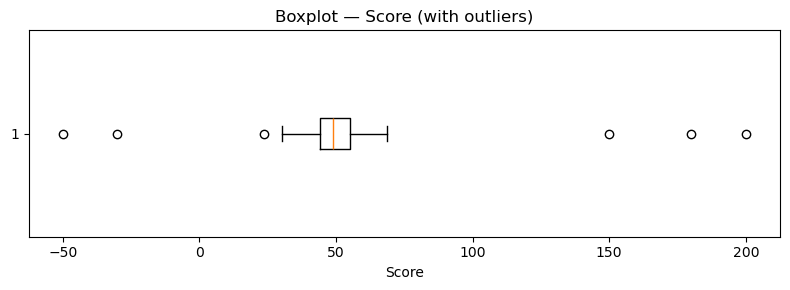

In [60]:
# Visualize the outliers with a boxplot
fig, ax = plt.subplots(figsize=(8, 3))
ax.boxplot(df_outlier['Score'], vert=False)
ax.set_title('Boxplot — Score (with outliers)')
ax.set_xlabel('Score')
plt.tight_layout()
plt.show()

### 6.1 IQR Method (Interquartile Range)

The IQR is the range between the 25th percentile (Q1) and the 75th percentile (Q3).  
Any value **below Q1 − 1.5×IQR** or **above Q3 + 1.5×IQR** is considered an outlier.

This is the same logic used by **boxplots** to draw whiskers.

In [61]:
# Step 1: Calculate Q1, Q3, and IQR
Q1 = df_outlier['Score'].quantile(0.25)
Q3 = df_outlier['Score'].quantile(0.75)
IQR = Q3 - Q1

print(f"Q1 (25th percentile): {Q1:.2f}")
print(f"Q3 (75th percentile): {Q3:.2f}")
print(f"IQR: {IQR:.2f}")

# Step 2: Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"\nLower Bound: {lower_bound:.2f}")
print(f"Upper Bound: {upper_bound:.2f}")

Q1 (25th percentile): 43.98
Q3 (75th percentile): 55.13
IQR: 11.15

Lower Bound: 27.26
Upper Bound: 71.86


In [62]:
# Step 3: Filter out outliers
df_iqr_clean = df_outlier[(df_outlier['Score'] >= lower_bound) & (df_outlier['Score'] <= upper_bound)]

# Count removed outliers
outliers_removed = len(df_outlier) - len(df_iqr_clean)
print(f"Original rows: {len(df_outlier)}")
print(f"Rows after IQR removal: {len(df_iqr_clean)}")
print(f"Outliers removed: {outliers_removed}")

Original rows: 105
Rows after IQR removal: 99
Outliers removed: 6


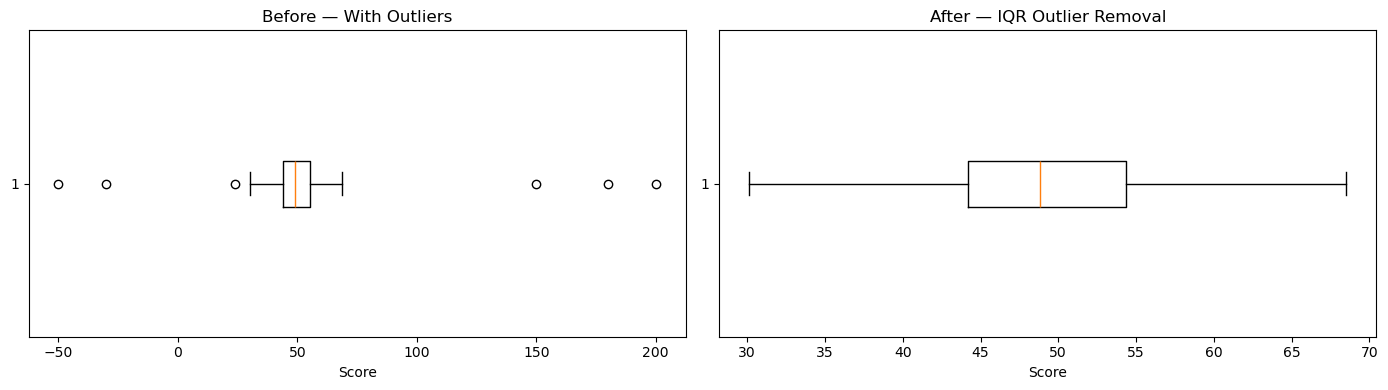

In [63]:
# Visualize Before vs After
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].boxplot(df_outlier['Score'], vert=False)
axes[0].set_title('Before — With Outliers')
axes[0].set_xlabel('Score')

axes[1].boxplot(df_iqr_clean['Score'], vert=False)
axes[1].set_title('After — IQR Outlier Removal')
axes[1].set_xlabel('Score')

plt.tight_layout()
plt.show()

### 6.2 Z-Score Method

The Z-score measures how many **standard deviations** a value is from the mean.  
Values with **|z| > 3** are typically considered outliers (beyond 3 standard deviations).

⚠️ Works best when data is **normally distributed**.

In [64]:
# Calculate Z-scores
z_scores = stats.zscore(df_outlier['Score'])

# Show Z-scores for the outlier values
df_outlier_z = df_outlier.copy()
df_outlier_z['Z_Score'] = z_scores
df_outlier_z['Is_Outlier'] = abs(z_scores) > 3

print("Rows flagged as outliers (|z| > 3):")
df_outlier_z[df_outlier_z['Is_Outlier']]

Rows flagged as outliers (|z| > 3):


,Score,Z_Score,Is_Outlier
100,150.0,3.732737,True
101,-30.0,-3.048287,True
102,200.0,5.616355,True
103,-50.0,-3.801734,True
104,180.0,4.862908,True


In [65]:
# Remove outliers
df_zscore_clean = df_outlier[abs(z_scores) < 3]

outliers_removed = len(df_outlier) - len(df_zscore_clean)
print(f"Original rows: {len(df_outlier)}")
print(f"Rows after Z-Score removal: {len(df_zscore_clean)}")
print(f"Outliers removed: {outliers_removed}")

Original rows: 105
Rows after Z-Score removal: 100
Outliers removed: 5


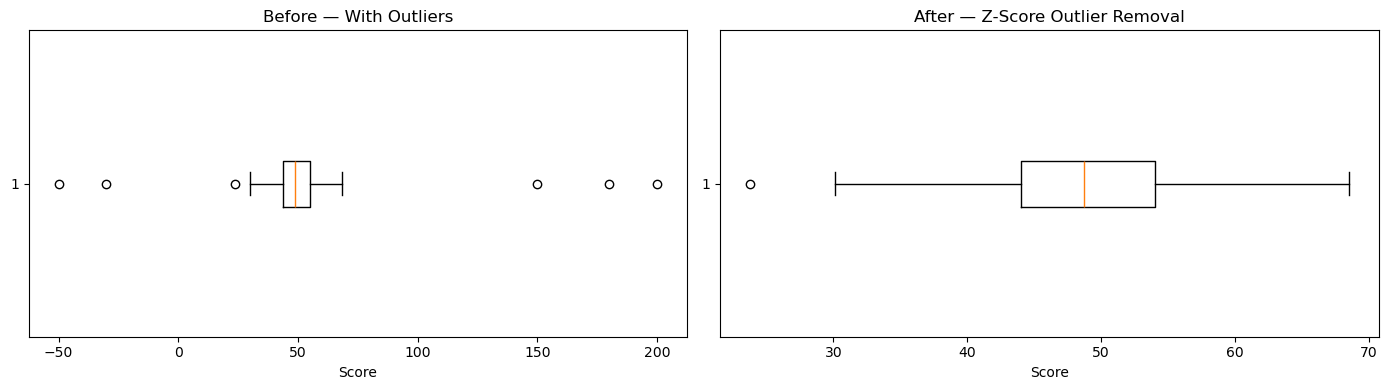

In [66]:
# Visualize Before vs After
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].boxplot(df_outlier['Score'], vert=False)
axes[0].set_title('Before — With Outliers')
axes[0].set_xlabel('Score')

axes[1].boxplot(df_zscore_clean['Score'], vert=False)
axes[1].set_title('After — Z-Score Outlier Removal')
axes[1].set_xlabel('Score')

plt.tight_layout()
plt.show()

### 6.3 Capping / Winsorization

Instead of **removing** outliers, you **clip** extreme values to a defined range.  
This preserves the number of rows while reducing the impact of extreme values.

✅ Useful when you **cannot afford to lose data points**.

In [67]:
# Define percentile boundaries
lower_cap = df_outlier['Score'].quantile(0.01)
upper_cap = df_outlier['Score'].quantile(0.99)

print(f"Lower cap (1st percentile): {lower_cap:.2f}")
print(f"Upper cap (99th percentile): {upper_cap:.2f}")

# Clip the values
df_capped = df_outlier.copy()
df_capped['Score'] = df_capped['Score'].clip(lower_cap, upper_cap)

print(f"\nRows preserved: {len(df_capped)} (same as original — no data lost!)")
df_capped.describe()

Lower cap (1st percentile): -27.85
Upper cap (99th percentile): 178.80

Rows preserved: 105 (same as original — no data lost!)


,Score
count,105.000000
mean,50.933883
std,24.706150
min,-27.847898
25%,43.982934
50%,48.843517
75%,55.132674
max,178.800000


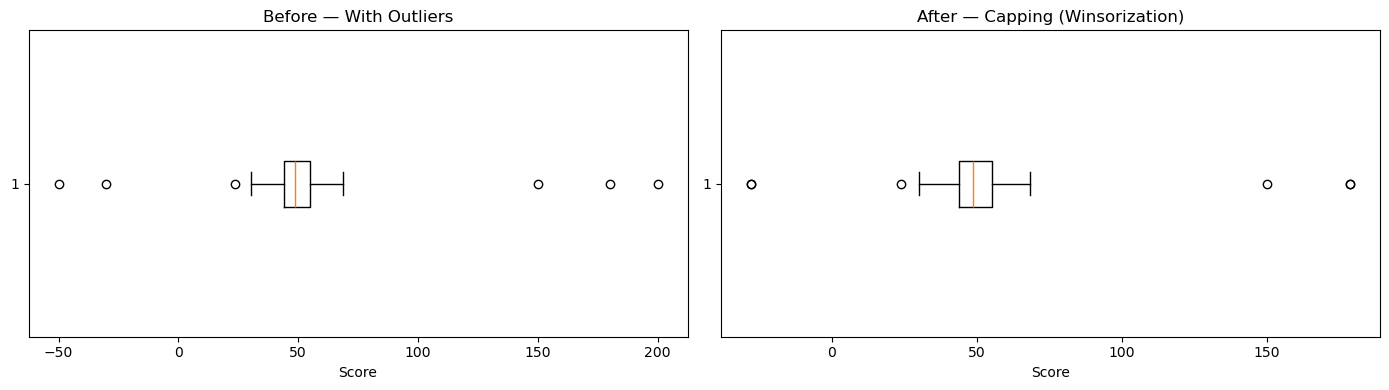

In [68]:
# Visualize Before vs After
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].boxplot(df_outlier['Score'], vert=False)
axes[0].set_title('Before — With Outliers')
axes[0].set_xlabel('Score')

axes[1].boxplot(df_capped['Score'], vert=False)
axes[1].set_title('After — Capping (Winsorization)')
axes[1].set_xlabel('Score')

plt.tight_layout()
plt.show()

### 6.4 Comparison: All Three Methods Side by Side

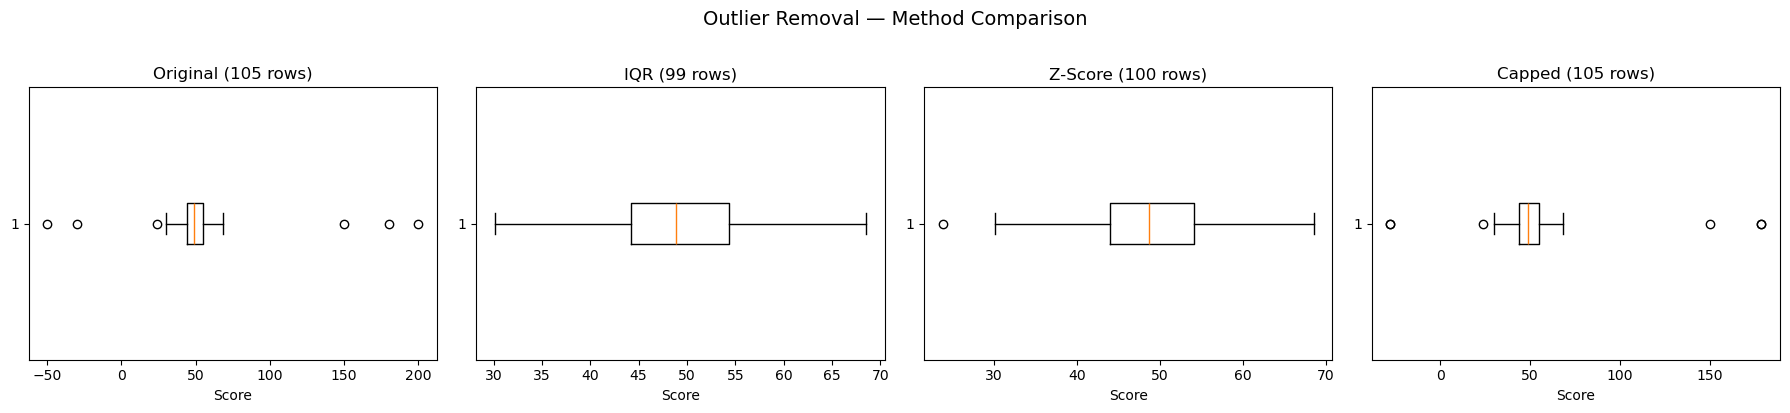

In [69]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

axes[0].boxplot(df_outlier['Score'], vert=False)
axes[0].set_title(f'Original ({len(df_outlier)} rows)')

axes[1].boxplot(df_iqr_clean['Score'], vert=False)
axes[1].set_title(f'IQR ({len(df_iqr_clean)} rows)')

axes[2].boxplot(df_zscore_clean['Score'], vert=False)
axes[2].set_title(f'Z-Score ({len(df_zscore_clean)} rows)')

axes[3].boxplot(df_capped['Score'], vert=False)
axes[3].set_title(f'Capped ({len(df_capped)} rows)')

for ax in axes:
    ax.set_xlabel('Score')

plt.suptitle('Outlier Removal — Method Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 📝 Summary

| Step | Technique | When to Use |
|------|-----------|-------------|
| **Merge** | `pd.merge()` with inner/left/right/outer | Combining multiple data sources |
| **Detect Missing** | `info()`, `isnull().sum()` | Always — first step of any analysis |
| **Fill Missing (Mean)** | `fillna(mean())` or `SimpleImputer(strategy='mean')` | Normally distributed numerical data |
| **Fill Missing (Median)** | `fillna(median())` or `SimpleImputer(strategy='median')` | Skewed data / data with outliers |
| **Fill Missing (ffill/bfill)** | `ffill()` / `bfill()` | Time-series or sequential data |
| **Drop Missing** | `dropna()` | When missing data is minimal |
| **Ordinal Encoding** | Manual `map()` or `OrdinalEncoder` | Features with natural order |
| **Label Encoding** | `LabelEncoder` | Target/label column encoding |
| **One-Hot Encoding** | `OneHotEncoder` or `pd.get_dummies()` | Nominal features (no order) |
| **Outlier Removal (IQR)** | Q1 − 1.5×IQR to Q3 + 1.5×IQR | General use, skewed data |
| **Outlier Removal (Z-Score)** | Remove where \|z\| > 3 | Normally distributed data |
| **Outlier Capping** | `clip()` to percentile bounds | When you can't lose rows |